### Maintaining context
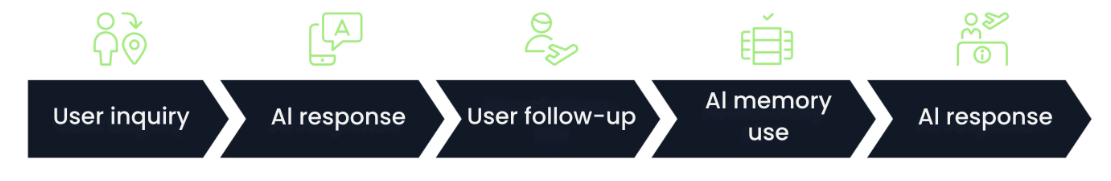

- Track a chat history with a `Conversation` class

### Conversation class
- Can store a history of prior messages

In [1]:
from llama_cpp import Llama

class Conversation:
    def __init__(self, llm: Llama, system_prompt: '', history =[]):
        self.llm = llm
        self.system_prompt = system_prompt
        self.history = [{'role': 'system', 'content': self.system_prompt}] + history

    def create_completion(self, user_prompt: ''):
        self.history.append({'role': 'user', 'content': user_prompt})
        output = self.llm.create_chat_completion(messages=self.history)
        conversation_result = output['choices'][0]['message']
        self.history.append(conversation_result)
        return conversation_result['content']

### Running a multi-turn conversation

In [2]:
llm = Llama(model_path='models/Meta-Llama-3.1-8B-Instruct-Q5_K_S.gguf',
            n_ctx=8192,
            n_gpu_layers=1,
            n_threads=8,
            )

llama_model_loader: loaded meta data with 33 key-value pairs and 292 tensors from models/Meta-Llama-3.1-8B-Instruct-Q5_K_S.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Meta Llama 3.1 8B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str              = Meta-Llama-3.1
llama_model_loader: - kv   5:                         general.size_label str              = 8B
llama_model_loader: - kv   6:                            general.license str              = llama3.1
llama_model_loader: - kv   7

In [3]:
conversation = Conversation(llm, system_prompt='You are a virtual travel assistant helping with planning trips.')

In [4]:
response1 = conversation.create_completion('What are some destinations in France for a short weekend break?')

llama_perf_context_print:        load time =    3970.66 ms
llama_perf_context_print: prompt eval time =    3970.24 ms /    58 tokens (   68.45 ms per token,    14.61 tokens per second)
llama_perf_context_print:        eval time =  106475.24 ms /   504 runs   (  211.26 ms per token,     4.73 tokens per second)
llama_perf_context_print:       total time =  110982.20 ms /   562 tokens
llama_perf_context_print:    graphs reused =        501


In [5]:
print(f'Response 1: {response1}')

Response 1: France is a beautiful country with numerous destinations perfect for a short weekend break. Here are some suggestions:

1. **Paris**: The City of Light is a must-visit destination in France. Explore the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and enjoy the charming streets of Montmartre.
2. **Annecy**: Nicknamed the "Venice of the Alps," Annecy is a picturesque town surrounded by mountains and waterways. Enjoy water sports, hiking, and exploring the old town.
3. **Bordeaux**: World-renowned for its wine production, Bordeaux is a great destination for wine enthusiasts. Visit the Bordeaux Wine Museum, take a wine tour, and stroll along the Garonne River.
4. **Reims**: Located in the Champagne region, Reims is famous for its cathedral and champagne production. Visit the Reims Cathedral, champagne cellars, and enjoy a champagne tasting.
5. **Aix-en-Provence**: This charming town in the south of France is known for its thermal springs, beautiful architecture, and vibr

In [6]:
response2 = conversation.create_completion('How about Spain?')

Llama.generate: 562 prefix-match hit, remaining 14 prompt tokens to eval
llama_perf_context_print:        load time =    3970.66 ms
llama_perf_context_print: prompt eval time =    1097.89 ms /    14 tokens (   78.42 ms per token,    12.75 tokens per second)
llama_perf_context_print:        eval time =  122712.06 ms /   570 runs   (  215.28 ms per token,     4.65 tokens per second)
llama_perf_context_print:       total time =  124348.28 ms /   584 tokens
llama_perf_context_print:    graphs reused =        567


In [7]:
print(f'Response 2: {response2}')

Response 2: Spain is a fantastic destination for a short weekend break. Here are some suggestions:

1. **Barcelona**: The capital of Catalonia is a must-visit destination in Spain. Explore the works of Gaudí, visit the Sagrada Família, Park Güell, and stroll along La Rambla.
2. **Seville**: The charming capital of Andalusia is known for its beautiful architecture, vibrant cultural scene, and delicious cuisine. Visit the Seville Cathedral, explore the Alcázar Palace, and stroll along the Guadalquivir River.
3. **Madrid**: The capital of Spain is a great destination for art lovers, foodies, and nightlife enthusiasts. Visit the Prado Museum, explore the Royal Palace, and enjoy the lively streets of Malasaña.
4. **Valencia**: Located on the Mediterranean coast, Valencia is a beautiful city known for its stunning beaches, vibrant cultural scene, and delicious cuisine. Visit the City of Arts and Sciences, explore the old town, and enjoy the local markets.
5. **Granada**: The Alhambra palace 